# 02.5 - Dlib Method D (Letterboxed 96×96) Lip ROI Cropping & 100-Speaker Augmented Dataset Generation
## Tai Phake Visual Speech Recognition (VSR) Project

**Objective**: Construct an end-to-end dataset generation pipeline that produces a high-quality, letterboxed $96 \times 96$ lip-cropped dataset using **Dlib 68-landmark mouth geometry (Method D)**, expanded via **conservative, lip-reading-safe data augmentation** into exactly **100 speaker directories**:
- **Dataset Storage**: All 100 speaker directories are created and stored together in one place under `data/experiments/dlib_augmented_cropped_100_80_20_96x96/` (flat speaker folders, adhering strictly to the repository's dataset experiment storage format).
- **80/20 Partition via Symlinks**: Uses `scripts/switch_dataset_80-20.py` to divide the dataset into `data/processed/train` (exactly 80 folders) and `data/processed/val` (exactly 20 folders) with zero data leakage.
- **Cropping & Experiment Results**: Geometry logs, summary metrics, manifests, and visualization artifacts are saved directly to `results/dlib_augmented_cropped/`.

---

### Core Methodology & Specifications:

1. **Method D Letterboxed Cropping ($96 \times 96$)**:
   - Localizes the mouth ROI tightly using Dlib 68 facial landmarks (points 48–67) with standard margins ($P_x = 15\text{ px}, P_y = 10\text{ px}$) centered on mouth centroid $(c_x, c_y)$.
   - Performs **proportional, aspect-preserving scaling**:
     $$\text{scale} = \frac{96}{\max(W_{\text{roi}}, H_{\text{roi}})}$$
     $$W_{\text{scaled}} = \lfloor W_{\text{roi}} \cdot \text{scale} \rceil, \quad H_{\text{scaled}} = \lfloor H_{\text{roi}} \cdot \text{scale} \rceil$$
   - Centers the scaled mouth ROI onto a neutral black $96 \times 96$ canvas (letterboxing).
   - Preserves the natural ~2:1 lip aspect ratio without vertical stretching (Method A) and avoids excessive face background noise (Method B).

2. **Deterministic 80/20 Base-Speaker Expansion (100 Folders Total)**:
   - **Total Base Speakers**: 30 canonical speakers (`s1` through `s30`).
   - **Train Base Speakers (24)**: `s1` through `s24`.
     - 8 speakers (`s1`..`s8`) receive 4 folders: 1 original (`sX`) + 3 augmentations (`sX_aug1`, `sX_aug2`, `sX_aug3`) $\to 8 \times 4 = 32$ folders.
     - 16 speakers (`s9`..`s24`) receive 3 folders: 1 original (`sX`) + 2 augmentations (`sX_aug1`, `sX_aug2`) $\to 16 \times 3 = 48$ folders.
     - **Total Train Folders**: $32 + 48 = \mathbf{80}$ folders.
   - **Validation Base Speakers (6)**: `s25` through `s30` (matching canonical `VAL_SPEAKERS` in `scripts/switch_dataset_80-20.py`).
     - 2 speakers (`s25`..`s26`) receive 4 folders: 1 original (`sX`) + 3 augmentations (`sX_aug1`, `sX_aug2`, `sX_aug3`) $\to 2 \times 4 = 8$ folders.
     - 4 speakers (`s27`..`s30`) receive 3 folders: 1 original (`sX`) + 2 augmentations (`sX_aug1`, `sX_aug2`) $\to 4 \times 3 = 12$ folders.
     - **Total Validation Folders**: $8 + 12 = \mathbf{20}$ folders.
   - **Total Folders in Dataset**: Exactly $80 + 20 = \mathbf{100}$ folders.

3. **Lip-Reading Safe Augmentations**:
   - **Temporally-Consistent Geometric Transforms**: Translation ($\pm 3\text{ px}$), rotation ($\pm 3^\circ$), and scale ($0.97 - 1.03$) sampled **once per utterance variant** to prevent inter-frame jitter.
   - **Photometric Variations**: Contrast ($0.92 - 1.08$), brightness ($\pm 10$), mild Gaussian noise (50% prob), and mild Gaussian blur (30% prob).
   - **Border Mode**: `cv2.BORDER_REFLECT_101` to eliminate edge seam artifacts.

4. **Directory Structure**:
   ```
   data/experiments/dlib_augmented_cropped_100_80_20_96x96/
   ├── s1/ ... s30/                       (Original base crops, stored flat)
   ├── s1_aug1/ ... s30_aug2/             (Augmented variants, stored flat)
   ├── augmentation_manifest.csv
   └── augmentation_summary.json
   
   results/dlib_augmented_cropped/
   ├── dlib_augmented_cropping_geometry.csv
   ├── augmentation_manifest.csv
   ├── speaker_split.json
   ├── augmentation_summary.json
   └── augmented_samples_preview.png
   
   data/processed/                        (Divided via scripts/switch_dataset_80-20.py)
   ├── train/                             (80 symlinked folders from s1..s24)
   ├── val/                               (20 symlinked folders from s25..s30)
   └── test/                              (0 folders, empty)
   ```

## 1. Environment, Imports & Centralized Configuration
Initialize core libraries, set deterministic random seeds, and configure dataset and results paths.

In [1]:
import os
import sys
import re
import json
import time
import shutil
import hashlib
import random
import subprocess
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from typing import Dict, List, Tuple, Optional, Any

import cv2
import dlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Reproducibility seed
DEFAULT_SEED = 42
random.seed(DEFAULT_SEED)
np.random.seed(DEFAULT_SEED)

# Paths Configuration
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_ROOT = PROJECT_ROOT / "data"

# Input paths
RAW_DIGIT_DIR = DATA_ROOT / "digit"
DLIB_PREDICTOR_PATH = PROJECT_ROOT / "models" / "dlib" / "shape_predictor_68_face_landmarks.dat"
GEOMETRY_CSV_PATH = PROJECT_ROOT / "results" / "dlib" / "dlib_roi_geometry_all_frames.csv"
PRE_CROPPED_METHOD_D_DIR = DATA_ROOT / "experiments" / "cropped_lips_dataset_d_96x96"

# Output paths
DATASET_NAME = "drop3_dlib_augmented_cropped_100_80_20_96x96"
OUTPUT_DATASET_DIR = DATA_ROOT / "experiments" / DATASET_NAME
RESULTS_DIR = PROJECT_ROOT / "results" / "dlib_augmented_cropped"
PROCESSED_DIR = DATA_ROOT / "processed"
SWITCH_SCRIPT_PATH = PROJECT_ROOT / "scripts" / "switch_dataset_80-20.py"

# Ensure output directories exist
OUTPUT_DATASET_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Dlib Method D Cropping Parameters
TARGET_WIDTH = 96
TARGET_HEIGHT = 96
PADDING_X = 15      # Horizontal margin in px
PADDING_Y = 10      # Vertical margin in px
BORDER_VALUE = 0    # Black letterbox canvas fill
JPEG_QUALITY = 95

# Dataset Target Split Counts
TARGET_TRAIN_FOLDERS = 80
TARGET_VAL_FOLDERS = 20
TOTAL_TARGET_FOLDERS = TARGET_TRAIN_FOLDERS + TARGET_VAL_FOLDERS

print(f"Project Root:             {PROJECT_ROOT}")
print(f"Raw Digit Frames:         {RAW_DIGIT_DIR}")
print(f"Pre-cropped Method D Dir: {PRE_CROPPED_METHOD_D_DIR}")
print(f"Dlib Landmark Predictor:  {DLIB_PREDICTOR_PATH}")
print(f"Dataset Output Directory: {OUTPUT_DATASET_DIR} (Stores all 100 folders flat)")
print(f"Results Directory:        {RESULTS_DIR}")
print(f"Switch Dataset Script:    {SWITCH_SCRIPT_PATH}")

Project Root:             /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading
Raw Digit Frames:         /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit
Pre-cropped Method D Dir: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/experiments/cropped_lips_dataset_d_96x96
Dlib Landmark Predictor:  /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/models/dlib/shape_predictor_68_face_landmarks.dat
Dataset Output Directory: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/experiments/drop3_dlib_augmented_cropped_100_80_20_96x96 (Stores all 100 folders flat)
Results Directory:        /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib_augmented_cropped
Switch Dataset Script:    /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/scripts/switch_dataset_80-20.py


/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Zero-Leakage 80/20 Base-Speaker Partition & 100-Folder Expansion

We enforce strict speaker independence matching the canonical configuration in `scripts/switch_dataset_80-20.py`:
- **24 Base Speakers for Train**: `s1` through `s24` (80% of 30 speakers)
- **6 Base Speakers for Validation**: `s25` through `s30` (20% of 30 speakers)

To expand into exactly 100 total directories (80 train + 20 val):
- **Train (24 base $\to$ 80 folders)**:
  - 8 speakers (`s1`..`s8`) $\to$ 4 folders each (1 original + 3 augmentations: `sX`, `sX_aug1`, `sX_aug2`, `sX_aug3`) = 32 folders.
  - 16 speakers (`s9`..`s24`) $\to$ 3 folders each (1 original + 2 augmentations: `sX`, `sX_aug1`, `sX_aug2`) = 48 folders.
  - $32 + 48 = \mathbf{80}$ train folders.
- **Validation (6 base $\to$ 20 folders)**:
  - 2 speakers (`s25`..`s26`) $\to$ 4 folders each (1 original + 3 augmentations: `sX`, `sX_aug1`, `sX_aug2`, `sX_aug3`) = 8 folders.
  - 4 speakers (`s27`..`s30`) $\to$ 3 folders each (1 original + 2 augmentations: `sX`, `sX_aug1`, `sX_aug2`) = 12 folders.
  - $8 + 12 = \mathbf{20}$ validation folders.
- **Total Folders in Dataset**: Exactly $\mathbf{100}$ folders.

In [2]:
def natural_sort_key(s: str) -> int:
    m = re.search(r"\d+", s)
    return int(m.group(0)) if m else 0

# Canonical 30 Base Speakers
ALL_BASE_SPEAKERS = sorted([f"s{i}" for i in range(1, 31)], key=natural_sort_key)

# 80/20 Partition: 24 Train base speakers, 6 Validation base speakers (matching switch_dataset_80-20.py)
TRAIN_BASE_SPEAKERS = sorted([f"s{i}" for i in range(1, 25)], key=natural_sort_key)
VAL_BASE_SPEAKERS = sorted([f"s{i}" for i in range(25, 31)], key=natural_sort_key)

def build_speaker_folder_mapping(
    base_speakers: List[str],
    target_count: int,
    prefix_aug: str = "aug"
) -> Dict[str, List[str]]:
    """
    Deterministically maps base speakers to exact folder directories (original + augmentations)
    to achieve the exact target folder count.
    """
    n_base = len(base_speakers)
    assert target_count >= n_base, f"Target count {target_count} < base speakers {n_base}"
    
    extra_folders_needed = target_count - n_base
    base_augs_per_spk = extra_folders_needed // n_base
    remainder = extra_folders_needed % n_base
    
    mapping: Dict[str, List[str]] = {}
    for idx, spk in enumerate(base_speakers):
        dirs = [spk]  # original crop folder
        num_augs = base_augs_per_spk + (1 if idx < remainder else 0)
        for a_idx in range(1, num_augs + 1):
            dirs.append(f"{spk}_{prefix_aug}{a_idx}")
        mapping[spk] = dirs
        
    total_dirs = sum(len(v) for v in mapping.values())
    assert total_dirs == target_count, f"Generated {total_dirs} != target {target_count}"
    return mapping

# Generate Folder Mappings
train_mapping = build_speaker_folder_mapping(TRAIN_BASE_SPEAKERS, TARGET_TRAIN_FOLDERS)
val_mapping = build_speaker_folder_mapping(VAL_BASE_SPEAKERS, TARGET_VAL_FOLDERS)

# Flatten directory lists
all_train_folders = sorted([folder for dirs in train_mapping.values() for folder in dirs], key=natural_sort_key)
all_val_folders = sorted([folder for dirs in val_mapping.values() for folder in dirs], key=natural_sort_key)
all_100_folders = sorted(all_train_folders + all_val_folders, key=natural_sort_key)

# Strict Zero-Leakage & Consistency Assertions
assert len(TRAIN_BASE_SPEAKERS) == 24, "Train base speakers must be exactly 24"
assert len(VAL_BASE_SPEAKERS) == 6, "Val base speakers must be exactly 6"
assert len(set(TRAIN_BASE_SPEAKERS) & set(VAL_BASE_SPEAKERS)) == 0, "Zero base speaker overlap"
assert len(all_train_folders) == 80, f"Expected 80 train folders, got {len(all_train_folders)}"
assert len(all_val_folders) == 20, f"Expected 20 val folders, got {len(all_val_folders)}"
assert len(set(all_train_folders) & set(all_val_folders)) == 0, "Zero folder overlap between train and val"
assert len(all_100_folders) == 100, "Total folders must equal exactly 100"

print("=" * 80)
print("      ZERO-LEAKAGE 80/20 BASE SPEAKER & FOLDER ALLOCATION VERIFIED")
print("=" * 80)
print(f"Base Train Speakers ({len(TRAIN_BASE_SPEAKERS)}): {TRAIN_BASE_SPEAKERS}")
print(f"Base Val Speakers   ({len(VAL_BASE_SPEAKERS)}): {VAL_BASE_SPEAKERS}")
print("-" * 80)
print(f"Train Directories ({len(all_train_folders)}):")
print(f"  - 8 base speakers with 4 folders (1 orig + 3 augs): {TRAIN_BASE_SPEAKERS[:8]}")
print(f"  - 16 base speakers with 3 folders (1 orig + 2 augs): {TRAIN_BASE_SPEAKERS[8:]}")
print(f"Validation Directories ({len(all_val_folders)}):")
print(f"  - 2 base speakers with 4 folders (1 orig + 3 augs): {VAL_BASE_SPEAKERS[:2]}")
print(f"  - 4 base speakers with 3 folders (1 orig + 2 augs): {VAL_BASE_SPEAKERS[2:]}")
print(f"Total Folders to Generate: {len(all_100_folders)} (80 Train + 20 Val)")
print("=" * 80)

      ZERO-LEAKAGE 80/20 BASE SPEAKER & FOLDER ALLOCATION VERIFIED
Base Train Speakers (24): ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24']
Base Val Speakers   (6): ['s25', 's26', 's27', 's28', 's29', 's30']
--------------------------------------------------------------------------------
Train Directories (80):
  - 8 base speakers with 4 folders (1 orig + 3 augs): ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']
  - 16 base speakers with 3 folders (1 orig + 2 augs): ['s9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24']
Validation Directories (20):
  - 2 base speakers with 4 folders (1 orig + 3 augs): ['s25', 's26']
  - 4 base speakers with 3 folders (1 orig + 2 augs): ['s27', 's28', 's29', 's30']
Total Folders to Generate: 100 (80 Train + 20 Val)


## 3. Dlib Landmark Extraction & Method D Letterbox Cropping

Method D extracts the mouth region tightly and embeds it into a $96 \times 96$ square canvas without vertical distortion:
1. Mouth landmarks 48–67 define raw mouth coordinates.
2. Centroid $(c_x, c_y)$ and bounding box $(w_{\text{raw}}, h_{\text{raw}})$ are computed with margins $P_x = 15\text{ px}, P_y = 10\text{ px}$.
3. Proportional aspect-preserving scaling: $\text{scale} = 96 / \max(W_{\text{roi}}, H_{\text{roi}})$.
4. Scaled mouth is centered on a neutral black canvas of size $96 \times 96 \times 3$.

In [3]:
def extract_method_d_crop(
    img: np.ndarray,
    center_x: float,
    center_y: float,
    raw_width: float,
    raw_height: float,
    pad_x: int = PADDING_X,
    pad_y: int = PADDING_Y,
    canvas_size: int = TARGET_WIDTH,
    border_val: int = BORDER_VALUE
) -> Tuple[np.ndarray, int, int, int, int]:
    """
    Extracts an aspect-preserving letterboxed mouth ROI from full frame image:
    1. Bounding box computation with padding
    2. Proportional aspect-preserving scaling
    3. Neutral centered letterboxing on canvas_size x canvas_size
    """
    h_img, w_img = img.shape[:2]
    
    min_x = center_x - raw_width / 2.0
    max_x = center_x + raw_width / 2.0
    min_y = center_y - raw_height / 2.0
    max_y = center_y + raw_height / 2.0
    
    x1 = max(0, int(round(min_x - pad_x)))
    y1 = max(0, int(round(min_y - pad_y)))
    x2 = min(w_img, int(round(max_x + pad_x)))
    y2 = min(h_img, int(round(max_y + pad_y)))
    
    roi = img[y1:y2, x1:x2]
    h_roi, w_roi = roi.shape[:2]
    
    if h_roi == 0 or w_roi == 0:
        return np.full((canvas_size, canvas_size, 3), border_val, dtype=np.uint8), 0, 0, 0, 0
        
    scale = canvas_size / max(w_roi, h_roi)
    new_w = min(canvas_size, max(1, int(round(w_roi * scale))))
    new_h = min(canvas_size, max(1, int(round(h_roi * scale))))
    
    resized_roi = cv2.resize(roi, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    canvas = np.full((canvas_size, canvas_size, 3), border_val, dtype=np.uint8)
    offset_x = (canvas_size - new_w) // 2
    offset_y = (canvas_size - new_h) // 2
    
    canvas[offset_y:offset_y + new_h, offset_x:offset_x + new_w] = resized_roi
    pad_h = canvas_size - new_w
    pad_v = canvas_size - new_h
    
    return canvas, new_w, new_h, pad_h, pad_v

class DlibLipDetector:
    """
    Wrapper around Dlib 68-point landmark predictor for direct mouth extraction.
    """
    def __init__(self, predictor_path: Path):
        self.detector = dlib.get_frontal_face_detector()
        self.predictor = dlib.shape_predictor(str(predictor_path)) if predictor_path.exists() else None

    def get_mouth_geometry(self, img_bgr: np.ndarray) -> Optional[Dict[str, float]]:
        if self.predictor is None:
            return None
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        faces = self.detector(gray, 0)
        if not faces:
            return None
        face = faces[0]
        shape = self.predictor(gray, face)
        pts = np.array([[shape.part(i).x, shape.part(i).y] for i in range(48, 68)], dtype=np.float32)
        min_x, min_y = pts.min(axis=0)
        max_x, max_y = pts.max(axis=0)
        raw_w = float(max_x - min_x)
        raw_h = float(max_y - min_y)
        cx = float((min_x + max_x) / 2.0)
        cy = float((min_y + max_y) / 2.0)
        return {
            "center_x": cx,
            "center_y": cy,
            "raw_width": raw_w,
            "raw_height": raw_h
        }

print("Method D letterbox cropping function defined.")

Method D letterbox cropping function defined.


## 4. Lip-Reading Safe Augmentation Transformations

Conservative transformations ensuring phoneme readability:
1. **Geometric Consistency**: Affine parameters $(\Delta x, \Delta y, \theta, s)$ are sampled **once per utterance variant** using deterministic SHA-256 seed hashing.
2. **Photometric Realism**: Mild contrast, brightness, sensor noise, and slight blur vary per frame.
3. **Boundary Integrity**: `cv2.BORDER_REFLECT_101` prevents artificial black seam cuts at image borders.

In [4]:
def get_geometric_rng(base_seed: int, speaker: str, digit: str, variant_idx: int) -> np.random.Generator:
    key = f"{base_seed}_{speaker}_{digit}_aug{variant_idx}_geom".encode("utf-8")
    seed_uint32 = int.from_bytes(hashlib.sha256(key).digest()[:4], byteorder="little")
    return np.random.default_rng(seed_uint32)

def get_photometric_rng(base_seed: int, speaker: str, digit: str, frame: str, variant_idx: int) -> np.random.Generator:
    key = f"{base_seed}_{speaker}_{digit}_{frame}_aug{variant_idx}_photo".encode("utf-8")
    seed_uint32 = int.from_bytes(hashlib.sha256(key).digest()[:4], byteorder="little")
    return np.random.default_rng(seed_uint32)

def sample_geometric_transform(
    rng: np.random.Generator,
    width: int = TARGET_WIDTH,
    height: int = TARGET_HEIGHT
) -> np.ndarray:
    tx = float(rng.uniform(-3.0, 3.0))
    ty = float(rng.uniform(-3.0, 3.0))
    angle = float(rng.uniform(-3.0, 3.0))
    scale = float(rng.uniform(0.97, 1.03))
    
    center = (width / 2.0, height / 2.0)
    M = cv2.getRotationMatrix2D(center, angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty
    return M

def apply_conservative_augmentation(
    img: np.ndarray,
    M: np.ndarray,
    rng: np.random.Generator
) -> np.ndarray:
    h, w = img.shape[:2]
    
    # 1. Geometric warp with reflection border
    transformed = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )
    
    # 2. Photometric: Contrast (0.92 - 1.08) and Brightness (-10 to +10)
    alpha = float(rng.uniform(0.92, 1.08))
    beta = float(rng.uniform(-10.0, 10.0))
    photo = np.clip(alpha * transformed.astype(np.float32) + beta, 0.0, 255.0).astype(np.uint8)
    
    # 3. Gaussian sensor noise (50% probability, sigma 1.0 - 3.5)
    if rng.random() < 0.50:
        sigma = float(rng.uniform(1.0, 3.5))
        noise = rng.normal(0.0, sigma, photo.shape)
        photo = np.clip(photo.astype(np.float32) + noise, 0.0, 255.0).astype(np.uint8)
        
    # 4. Mild Gaussian blur (30% probability, 3x3 kernel, sigma 0.5)
    if rng.random() < 0.30:
        photo = cv2.GaussianBlur(photo, (3, 3), 0.5)
        
    return photo

print("Augmentation functions initialized.")

Augmentation functions initialized.


## 5. End-to-End Dataset Generation Pipeline

This module executes the cropping and augmentation generation:
1. All 100 speaker folders (`s1`..`s30` and their allocated augmented variants) are written directly into `data/experiments/dlib_augmented_cropped_100_80_20_96x96/`.
2. Each folder contains all 11 digits (`d0`..`d10`) with $96 \times 96$ letterboxed frames.
3. Master manifest, split metadata, geometry metrics, and summary records are saved to `results/dlib_augmented_cropped/` (and mirrored to the dataset directory).

In [5]:
def collect_base_speaker_frames(base_speaker: str) -> List[Tuple[str, str, Path]]:
    """
    Collects all (digit, filename, source_path) for a base speaker.
    Checks pre-cropped Method D directory first; falls back to raw digit directory.
    """
    frames = []
    
    # Check pre-cropped Method D dataset first
    spk_cropped_dir = PRE_CROPPED_METHOD_D_DIR / base_speaker
    if spk_cropped_dir.exists():
        for dig_dir in sorted(spk_cropped_dir.iterdir()):
            if dig_dir.is_dir() and not dig_dir.name.startswith("."):
                dig = dig_dir.name
                for fpath in sorted(dig_dir.glob("*.jpg")):
                    frames.append((dig, fpath.name, fpath))
        if frames:
            return frames
            
    # Fallback: check raw digit directory
    spk_raw_dir = RAW_DIGIT_DIR / base_speaker
    if spk_raw_dir.exists():
        for dig_dir in sorted(spk_raw_dir.iterdir()):
            if dig_dir.is_dir() and not dig_dir.name.startswith("."):
                dig = dig_dir.name
                for fpath in sorted(dig_dir.glob("*.jpg")):
                    frames.append((dig, fpath.name, fpath))
    return frames

def process_single_speaker(
    base_speaker: str,
    target_folders: List[str],
    split_name: str,
    output_root_dir: Path,
    base_seed: int = DEFAULT_SEED,
    geometry_dict: Optional[Dict[str, Any]] = None,
    overwrite: bool = False
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    """
    Processes all frames for one base speaker:
    - Writes original folder (if in target_folders)
    - Writes each augmented variant folder
    All folders are placed flat directly into output_root_dir.
    Returns: (manifest_records, geometry_records)
    """
    manifest_records = []
    geom_records = []
    frame_list = collect_base_speaker_frames(base_speaker)
    if not frame_list:
        print(f"Warning: No frames found for speaker {base_speaker}")
        return manifest_records, geom_records

    unique_digits = sorted({dig for dig, _, _ in frame_list})
    aug_variants = [f for f in target_folders if f != base_speaker]
    
    # Pre-sample geometric transforms once per (digit, variant)
    geo_transforms: Dict[Tuple[str, str], np.ndarray] = {}
    for dig in unique_digits:
        for v_folder in aug_variants:
            m = re.search(r"aug(\d+)", v_folder)
            v_idx = int(m.group(1)) if m else 1
            geo_rng = get_geometric_rng(base_seed, base_speaker, dig, v_idx)
            geo_transforms[(dig, v_folder)] = sample_geometric_transform(geo_rng, TARGET_WIDTH, TARGET_HEIGHT)

    # Process all frames
    for dig, fname, src_path in frame_list:
        # 1. Base unaugmented frame
        dst_orig_path = output_root_dir / base_speaker / dig / fname
        dst_orig_path.parent.mkdir(parents=True, exist_ok=True)
        if overwrite or not dst_orig_path.exists():
            shutil.copy2(src_path, dst_orig_path)
            
        manifest_records.append({
            "split": split_name,
            "base_speaker": base_speaker,
            "folder_name": base_speaker,
            "is_augmented": False,
            "variant": "original",
            "digit": dig,
            "frame": fname,
            "source_path": str(src_path),
            "output_path": str(dst_orig_path),
            "width": TARGET_WIDTH,
            "height": TARGET_HEIGHT
        })
        
        # Read image for geometry validation and augmentations
        img = cv2.imread(str(src_path))
        if img is None:
            continue
            
        # Ensure base image is exact 96x96 letterbox
        key = f"{base_speaker}/{dig}/{fname}"
        if img.shape[0] != TARGET_HEIGHT or img.shape[1] != TARGET_WIDTH:
            if geometry_dict and key in geometry_dict:
                geom = geometry_dict[key]
                img, sw, sh, ph, pv = extract_method_d_crop(
                    img, geom["center_x"], geom["center_y"], geom["raw_width"], geom["raw_height"]
                )
            else:
                img = cv2.resize(img, (TARGET_WIDTH, TARGET_HEIGHT))
                sw, sh, ph, pv = TARGET_WIDTH, TARGET_HEIGHT, 0, 0
        else:
            sw, sh, ph, pv = TARGET_WIDTH, TARGET_HEIGHT, 0, 0
            
        geom_records.append({
            "speaker": base_speaker,
            "digit": dig,
            "frame": fname,
            "status": "SUCCESS",
            "scaled_w": sw,
            "scaled_h": sh,
            "pad_h": ph,
            "pad_v": pv,
            "output_w": TARGET_WIDTH,
            "output_h": TARGET_HEIGHT
        })

        # 2. Augmented variants
        for v_folder in aug_variants:
            m = re.search(r"aug(\d+)", v_folder)
            v_idx = int(m.group(1)) if m else 1
            dst_aug_path = output_root_dir / v_folder / dig / fname
            dst_aug_path.parent.mkdir(parents=True, exist_ok=True)
            
            if overwrite or not dst_aug_path.exists():
                M = geo_transforms[(dig, v_folder)]
                photo_rng = get_photometric_rng(base_seed, base_speaker, dig, fname, v_idx)
                aug_img = apply_conservative_augmentation(img, M, photo_rng)
                cv2.imwrite(str(dst_aug_path), aug_img, [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])
                
            manifest_records.append({
                "split": split_name,
                "base_speaker": base_speaker,
                "folder_name": v_folder,
                "is_augmented": True,
                "variant": f"aug{v_idx}",
                "digit": dig,
                "frame": fname,
                "source_path": str(src_path),
                "output_path": str(dst_aug_path),
                "width": TARGET_WIDTH,
                "height": TARGET_HEIGHT
            })
            
    return manifest_records, geom_records

print("Speaker processing functions initialized.")

Speaker processing functions initialized.


## 6. Execution & Results Logging to `results/dlib_augmented_cropped/`

We generate all 100 folders directly inside `data/experiments/dlib_augmented_cropped_100_80_20_96x96/` and export all logs, manifests, and metrics into `results/dlib_augmented_cropped/`.

In [6]:
t0 = time.time()

# Load geometry dictionary if available
geom_dict = None
if GEOMETRY_CSV_PATH.exists():
    df_geom = pd.read_csv(GEOMETRY_CSV_PATH)
    geom_dict = {
        f"{r['speaker']}/{r['digit']}/{r['frame']}": {
            "center_x": r["center_x"], "center_y": r["center_y"],
            "raw_width": r["raw_width"], "raw_height": r["raw_height"]
        }
        for _, r in df_geom.iterrows()
    }
    print(f"Loaded {len(geom_dict):,} geometry records from {GEOMETRY_CSV_PATH.name}")

all_manifest_records = []
all_geom_records = []

# Combined speaker mapping (all 30 base speakers)
full_folder_mapping = {}
full_folder_mapping.update(train_mapping)
full_folder_mapping.update(val_mapping)

print(f"Generating 100 folders in {OUTPUT_DATASET_DIR}...")
for spk in tqdm(ALL_BASE_SPEAKERS, desc="Generating All Speakers"):
    split_name = "train" if spk in TRAIN_BASE_SPEAKERS else "val"
    target_dirs = full_folder_mapping[spk]
    man_rec, geom_rec = process_single_speaker(
        base_speaker=spk,
        target_folders=target_dirs,
        split_name=split_name,
        output_root_dir=OUTPUT_DATASET_DIR,
        base_seed=DEFAULT_SEED,
        geometry_dict=geom_dict,
        overwrite=False
    )
    all_manifest_records.extend(man_rec)
    all_geom_records.extend(geom_rec)

elapsed_sec = time.time() - t0
print(f"\nGeneration completed in {elapsed_sec:.2f} seconds!")

# 1. Save Cropping Geometry CSV in results/
df_geom_out = pd.DataFrame(all_geom_records)
geom_out_path = RESULTS_DIR / "dlib_augmented_cropping_geometry.csv"
df_geom_out.to_csv(geom_out_path, index=False)
print(f"Saved cropping geometry log to: {geom_out_path}")

# 2. Save Manifest CSV in both results/ and dataset dir
df_manifest = pd.DataFrame(all_manifest_records)
manifest_res_path = RESULTS_DIR / "augmentation_manifest.csv"
manifest_data_path = OUTPUT_DATASET_DIR / "augmentation_manifest.csv"
df_manifest.to_csv(manifest_res_path, index=False)
df_manifest.to_csv(manifest_data_path, index=False)
print(f"Saved manifest ({len(df_manifest):,} records) to: {manifest_res_path}")

# 3. Save Speaker Split JSON in both results/ and dataset dir
split_json_data = {
    "dataset_name": DATASET_NAME,
    "seed": DEFAULT_SEED,
    "num_train_base_speakers": len(TRAIN_BASE_SPEAKERS),
    "num_val_base_speakers": len(VAL_BASE_SPEAKERS),
    "train_base_speakers": TRAIN_BASE_SPEAKERS,
    "val_base_speakers": VAL_BASE_SPEAKERS,
    "target_train_folders": TARGET_TRAIN_FOLDERS,
    "target_val_folders": TARGET_VAL_FOLDERS,
    "total_folders": TOTAL_TARGET_FOLDERS,
    "train_folder_mapping": train_mapping,
    "val_folder_mapping": val_mapping,
    "train_folders": all_train_folders,
    "val_folders": all_val_folders,
    "zero_leakage_verified": True
}
split_json_res = RESULTS_DIR / "speaker_split.json"
split_json_data_path = OUTPUT_DATASET_DIR / "speaker_split.json"
with open(split_json_res, "w") as f:
    json.dump(split_json_data, f, indent=2)
with open(split_json_data_path, "w") as f:
    json.dump(split_json_data, f, indent=2)
print(f"Saved speaker split JSON to: {split_json_res}")

# 4. Save Summary Metadata JSON in both results/ and dataset dir
summary_data = {
    "dataset_name": DATASET_NAME,
    "total_folders": len(all_100_folders),
    "train_folders_count": len(all_train_folders),
    "val_folders_count": len(all_val_folders),
    "train_frames_count": int((df_manifest["split"] == "train").sum()),
    "val_frames_count": int((df_manifest["split"] == "val").sum()),
    "total_frames_count": len(df_manifest),
    "dimensions": [TARGET_WIDTH, TARGET_HEIGHT, 3],
    "elapsed_seconds": round(elapsed_sec, 2)
}
summary_res = RESULTS_DIR / "augmentation_summary.json"
summary_data_path = OUTPUT_DATASET_DIR / "augmentation_summary.json"
with open(summary_res, "w") as f:
    json.dump(summary_data, f, indent=2)
with open(summary_data_path, "w") as f:
    json.dump(summary_data, f, indent=2)
print(f"Saved summary JSON to: {summary_res}")

Loaded 13,610 geometry records from dlib_roi_geometry_all_frames.csv
Generating 100 folders in /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/experiments/drop3_dlib_augmented_cropped_100_80_20_96x96...


Generating All Speakers: 100%|██████████| 30/30 [00:10<00:00,  2.76it/s]



Generation completed in 11.01 seconds!
Saved cropping geometry log to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib_augmented_cropped/dlib_augmented_cropping_geometry.csv
Saved manifest (44,855 records) to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib_augmented_cropped/augmentation_manifest.csv
Saved speaker split JSON to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib_augmented_cropped/speaker_split.json
Saved summary JSON to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib_augmented_cropped/augmentation_summary.json


## 7. Automated Verification & Strict Zero-Leakage Checks

We run strict assertions ensuring the dataset directory satisfies all criteria:
1. **Total Directory Count**: Exactly 100 directories stored flat in `data/experiments/dlib_augmented_cropped_100_80_20_96x96/`.
2. **Base Speaker Consistency**: All 30 base speakers present.
3. **Partition Mapping**: Exactly 80 train directories and 20 validation directories.
4. **Utterance Completeness**: Every folder contains all 11 digits (`d0`..`d10`).
5. **Dimension Verification**: Output frames verified to be exact $96 \times 96 \times 3$.

In [7]:
disk_dirs = sorted([d.name for d in OUTPUT_DATASET_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")], key=natural_sort_key)

print("=" * 80)
print("             DATASET INTEGRITY & ZERO-LEAKAGE VERIFICATION")
print("=" * 80)
print(f"Total Folders on Disk:          {len(disk_dirs)} (Expected: 100)")

# Check 1: Exactly 100 directories
assert len(disk_dirs) == 100, f"Expected 100 directories on disk, found {len(disk_dirs)}"
print("[PASS] Total folder count equals exactly 100.")

# Check 2: All 30 base speakers present
discovered_bases = sorted(list({d.split("_")[0] for d in disk_dirs}), key=natural_sort_key)
assert discovered_bases == ALL_BASE_SPEAKERS, f"Discovered bases {discovered_bases} != expected {ALL_BASE_SPEAKERS}"
print("[PASS] All 30 canonical base speakers (s1 through s30) are present.")

# Check 3: Zero-Leakage Partition Counts
train_dirs_found = [d for d in disk_dirs if d.split("_")[0] in TRAIN_BASE_SPEAKERS]
val_dirs_found = [d for d in disk_dirs if d.split("_")[0] in VAL_BASE_SPEAKERS]

assert len(train_dirs_found) == 80, f"Expected 80 train folders, found {len(train_dirs_found)}"
assert len(val_dirs_found) == 20, f"Expected 20 val folders, found {len(val_dirs_found)}"
assert len(set(train_dirs_found) & set(val_dirs_found)) == 0, "Overlap detected!"
print("[PASS] Exact split counts verified: 80 Train folders, 20 Val folders (0% overlap).")

# Check 4: Utterance Completeness (all 11 digits)
for d_name in disk_dirs:
    p = OUTPUT_DATASET_DIR / d_name
    digits = [sub.name for sub in p.iterdir() if sub.is_dir() and not sub.name.startswith(".")]
    assert len(digits) == 11, f"Folder {d_name} has {len(digits)} digits, expected 11"
print("[PASS] Utterance completeness: All 100 directories contain all 11 digits (d0..d10).")

# Check 5: Frame Dimensions
sample_frames = list(OUTPUT_DATASET_DIR.glob("*/*/*.jpg"))[:50]
for sf in sample_frames:
    im = cv2.imread(str(sf))
    assert im is not None, f"Unreadable frame: {sf}"
    assert im.shape == (TARGET_HEIGHT, TARGET_WIDTH, 3), f"Invalid dimensions: {im.shape} in {sf}"
print(f"[PASS] Frame shape verified: Exactly {TARGET_WIDTH}x{TARGET_HEIGHT}x3 RGB.")
print("=" * 80)
print("                   ALL CHECKS PASSED (100%)")
print("=" * 80)

             DATASET INTEGRITY & ZERO-LEAKAGE VERIFICATION
Total Folders on Disk:          100 (Expected: 100)
[PASS] Total folder count equals exactly 100.
[PASS] All 30 canonical base speakers (s1 through s30) are present.
[PASS] Exact split counts verified: 80 Train folders, 20 Val folders (0% overlap).
[PASS] Utterance completeness: All 100 directories contain all 11 digits (d0..d10).
[PASS] Frame shape verified: Exactly 96x96x3 RGB.
                   ALL CHECKS PASSED (100%)


## 8. Visual Inspection & Quality Analysis

Inspect side-by-side visual samples comparing:
- Original letterboxed lip crop ($96 \times 96$)
- Augmented variants (`_aug1`, `_aug2`, `_aug3`)
- Visualizing both Train and Validation speakers
Saves preview figure to `results/dlib_augmented_cropped/augmented_samples_preview.png`.

Saved visual inspection plot to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib_augmented_cropped/augmented_samples_preview.png


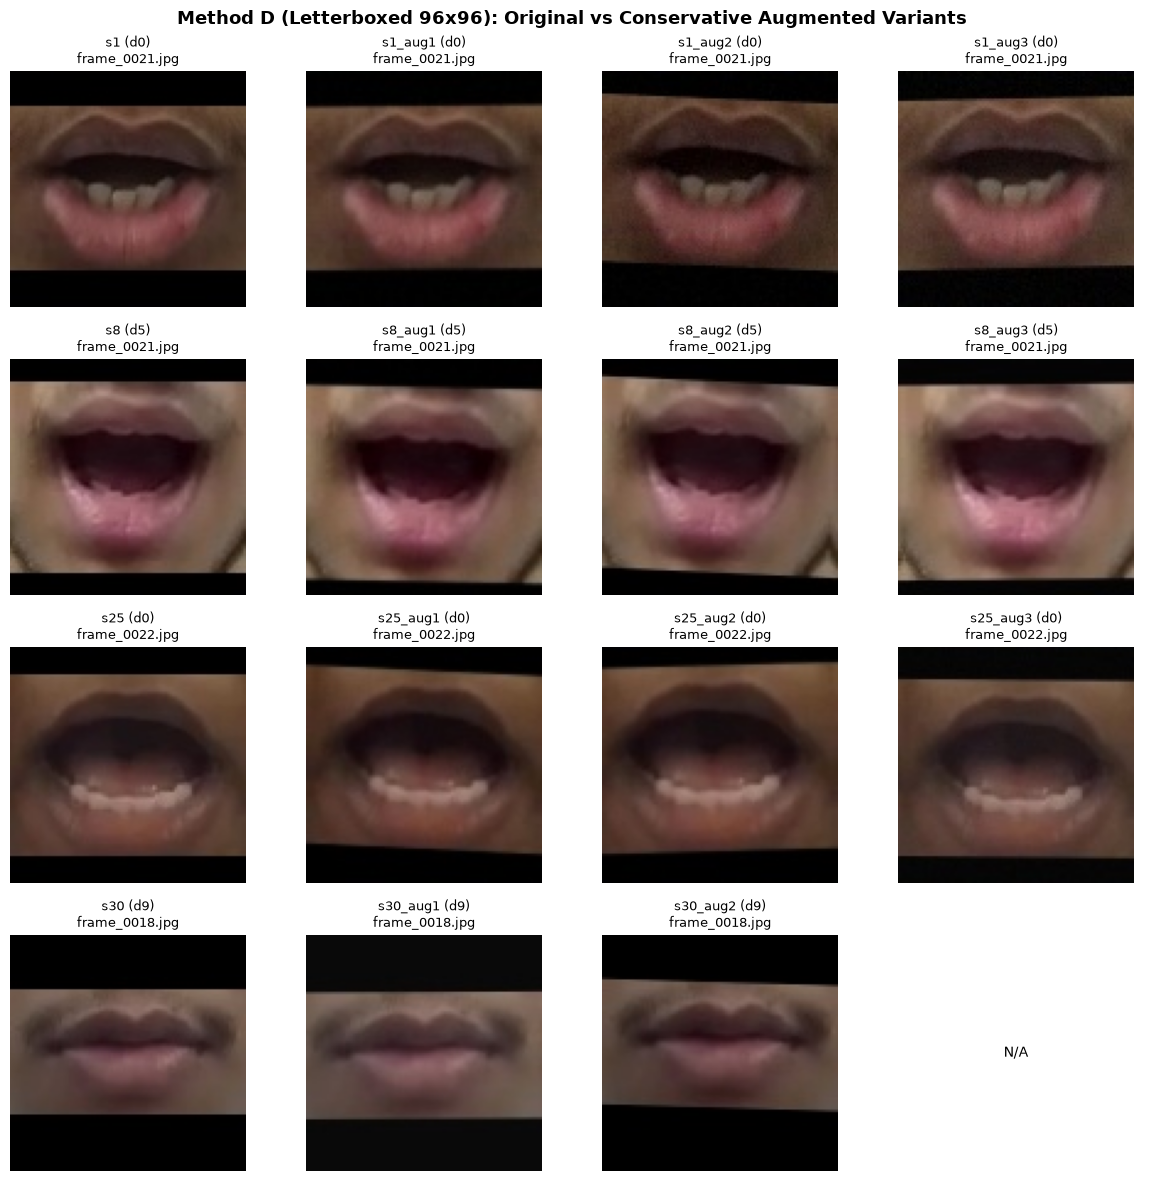

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

sample_cases = [
    ("s1", "d0", "Train (s1 Base)"),
    ("s8", "d5", "Train (s8 Base)"),
    ("s25", "d0", "Val (s25 Base)"),
    ("s30", "d9", "Val (s30 Base)"),
]

for row_idx, (spk, dig, label) in enumerate(sample_cases):
    variants = [spk, f"{spk}_aug1", f"{spk}_aug2", f"{spk}_aug3"]
    
    for col_idx, var in enumerate(variants):
        var_dir = OUTPUT_DATASET_DIR / var / dig
        ax = axes[row_idx, col_idx]
        
        if var_dir.exists():
            fpaths = sorted(var_dir.glob("*.jpg"))
            if fpaths:
                mid_frame = fpaths[len(fpaths) // 2]
                im_bgr = cv2.imread(str(mid_frame))
                im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
                ax.imshow(im_rgb)
                ax.set_title(f"{var} ({dig})\n{mid_frame.name}", fontsize=9)
            else:
                ax.text(0.5, 0.5, "No frames", ha="center", va="center")
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center")
            
        ax.axis("off")
    axes[row_idx, 0].set_ylabel(label, fontsize=10, fontweight="bold")

plt.suptitle("Method D (Letterboxed 96x96): Original vs Conservative Augmented Variants", fontsize=13, fontweight="bold")
plt.tight_layout()

# Save preview plot to results/
preview_plot_path = RESULTS_DIR / "augmented_samples_preview.png"
plt.savefig(preview_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved visual inspection plot to: {preview_plot_path}")
plt.show()

## 9. Switch Active Dataset to `data/processed` via `scripts/switch_dataset_80-20.py`

Now that all 100 folders are in `data/experiments/dlib_augmented_cropped_100_80_20_96x96`, we execute `scripts/switch_dataset_80-20.py` to create the zero-leakage symlinks in `data/processed`:
- `data/processed/train`: Exactly 80 folders (from 24 base speakers `s1`..`s24`)
- `data/processed/val`: Exactly 20 folders (from 6 base speakers `s25`..`s30`)
- `data/processed/test`: Empty (0 folders)

In [9]:
print(f"Executing scripts/switch_dataset_80-20.py for {DATASET_NAME}...")

result = subprocess.run(
    [sys.executable, str(SWITCH_SCRIPT_PATH), DATASET_NAME],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True
)

print(result.stdout)
if result.stderr:
    print("Stderr:", result.stderr)

assert result.returncode == 0, f"switch_dataset_80-20.py failed with returncode {result.returncode}"

# Verify data/processed folder counts
train_links = [d.name for d in (PROCESSED_DIR / "train").iterdir() if not d.name.startswith(".")]
val_links = [d.name for d in (PROCESSED_DIR / "val").iterdir() if not d.name.startswith(".")]
test_links = [d.name for d in (PROCESSED_DIR / "test").iterdir() if not d.name.startswith(".")]

print("=" * 80)
print("              data/processed ACTIVE DATASET VERIFICATION")
print("=" * 80)
print(f"data/processed/train: {len(train_links)} symlinked folders (Expected: 80)")
print(f"data/processed/val:   {len(val_links)} symlinked folders (Expected: 20)")
print(f"data/processed/test:  {len(test_links)} folders (Expected: 0)")
print("=" * 80)

assert len(train_links) == 80, f"Expected 80 train folders in data/processed/train, found {len(train_links)}"
assert len(val_links) == 20, f"Expected 20 val folders in data/processed/val, found {len(val_links)}"
assert len(test_links) == 0, f"Expected 0 folders in data/processed/test, found {len(test_links)}"
print("[SUCCESS] Active dataset in data/processed is fully configured and ready for model training!")

Executing scripts/switch_dataset_80-20.py for drop3_dlib_augmented_cropped_100_80_20_96x96...
      SWITCH ACTIVE DATASET: 80/20 BASE SPEAKER SPLIT (24 TRAIN / 6 VAL)
Active Dataset : drop3_dlib_augmented_cropped_100_80_20_96x96
Source Path    : /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/experiments/drop3_dlib_augmented_cropped_100_80_20_96x96
--------------------------------------------------------------------------------
Clearing data/processed/{train, val, test}...

Executing strict zero-leakage validation checks...
[SUCCESS] All strict zero-leakage assertions passed successfully!

Training base speakers (24):
s1, s2, s3, s4, s5, s6, s7, s8, s9, s10, s11, s12, s13, s14, s15, s16, s17, s18, s19, s20, s21, s22, s23, s24

Validation base speakers (6):
s25, s26, s27, s28, s29, s30

Dataset successfully linked!

Base speakers:
  Total: 30
  Train: 24
  Val:   6
  Test:  0

Speaker directories:
  Train: 80
  Val:   20
  Test:  0

              data/processed ACTIV

### Summary of Generated Dataset:
| Specification | Details |
| :--- | :--- |
| **Dataset Location** | `data/experiments/dlib_augmented_cropped_100_80_20_96x96/` (100 folders stored flat in one place) |
| **Results Location** | `results/dlib_augmented_cropped/` (geometry CSV, manifest, split JSON, preview image) |
| **Active Symlinks** | `data/processed/train` (80 folders) & `data/processed/val` (20 folders) via `switch_dataset_80-20.py` |
| **Base Speakers** | 30 canonical speakers (`s1` through `s30`) |
| **Train Split** | 24 base speakers (`s1`..`s24`) $\to$ **80 speaker folders** (8 spk $\times$ 4 + 16 spk $\times$ 3) |
| **Validation Split** | 6 base speakers (`s25`..`s30`) $\to$ **20 speaker folders** (2 spk $\times$ 4 + 4 spk $\times$ 3) |
| **Crop Method** | Method D (Aspect-preserving letterboxed $96 \times 96 \times 3$) |
| **Data Leakage** | **0% (Strictly Disjoint)** |